# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


In [5]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

In [6]:
import io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

In [7]:
# ── Run this cell in Google Colab to upload the CSV ──
from google.colab import files

uploaded = files.upload()                          # select Country-data.csv
csv_name = next(iter(uploaded))
df_raw = pd.read_csv(io.BytesIO(uploaded[csv_name]))

print(f'Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
df_raw.head()

Saving Country-data.csv to Country-data.csv
Dataset loaded: 167 rows × 10 columns


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [8]:
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
display(df_raw.head())
display(df_raw.describe(include='all').T)

Shape: (167, 10)
Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


##  Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [9]:
df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

numeric_cols = [c for c in df.columns if c != 'country']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

missing_before = df[numeric_cols].isna().sum().sum()
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(f'Rows after dedup   : {len(df)}')
print(f'Missing values fixed: {missing_before}')
print(f'Remaining NaN      : {df.isna().sum().sum()}')

Rows after dedup   : 167
Missing values fixed: 0
Remaining NaN      : 0


## Exploratory Data Analysis

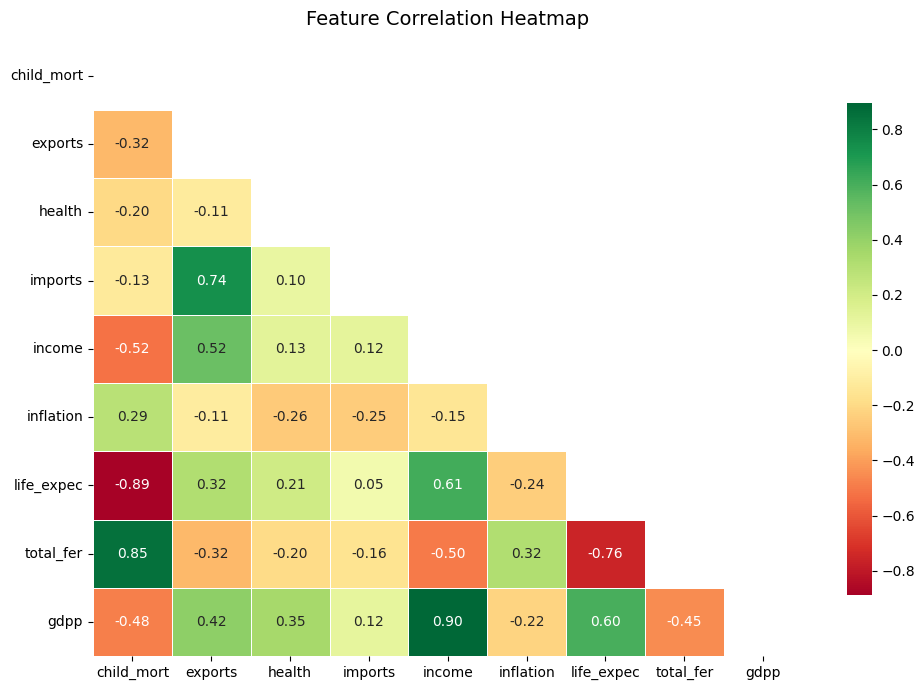

Strong negative correlations with child_mort:
life_expec   -0.886676
income       -0.524315
gdpp         -0.483032
exports      -0.318093


In [32]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print('Strong negative correlations with child_mort:')
print(corr['child_mort'].sort_values().head(4).to_string())

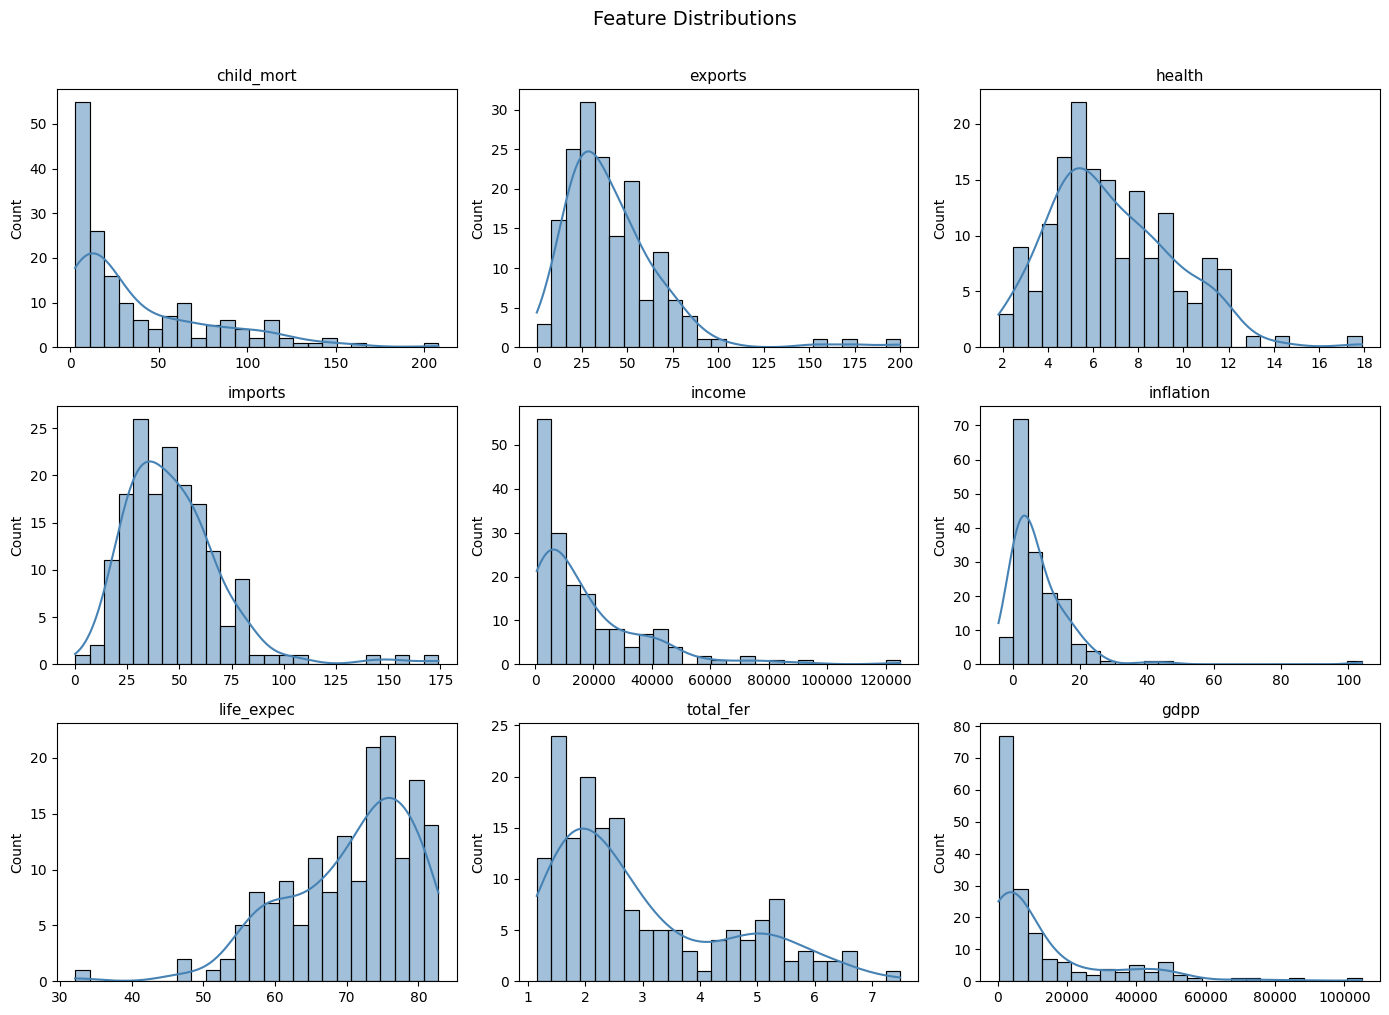

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=25)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

##  Feature Scaling

K-Means and DBSCAN rely on Euclidean distances, so features on very different scales would bias the distance metric.  
`StandardScaler` transforms each feature to zero mean and unit variance.

In [31]:
feature_matrix = df[numeric_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix)

print(f'Scaled feature matrix shape: {X_scaled.shape}')
print(f'Mean per feature: {X_scaled.mean(axis=0).round(2)}')
print(f'Std  per feature: {X_scaled.std(axis=0).round(2)}')

Scaled feature matrix shape: (167, 9)
Mean per feature: [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std  per feature: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


##  Choosing k

- **Elbow plot**-inertia drops steeply then flattens; the 'elbow' is the sweet spot.
- **Silhouette score** - ranges from -1 to 1; higher means better-separated clusters.

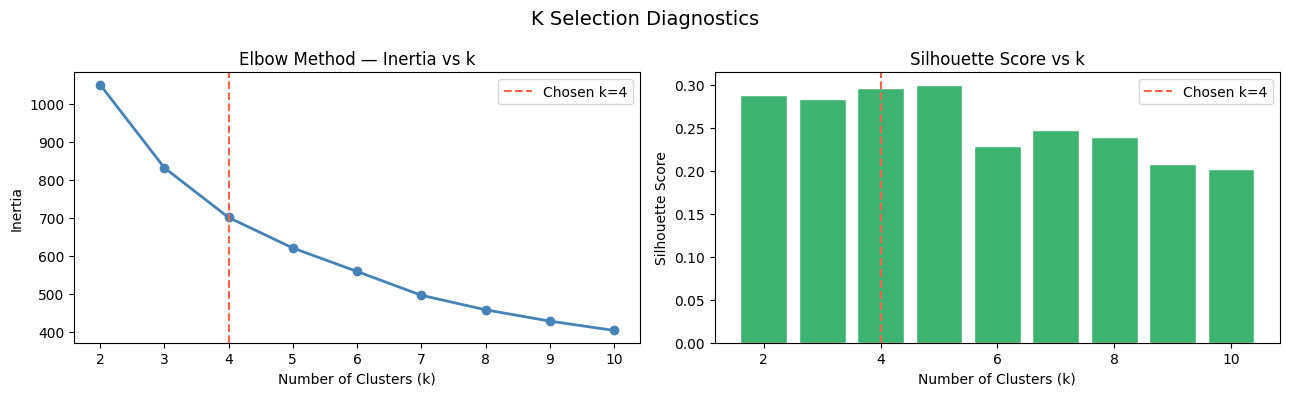

Highest silhouette score: 0.2993 at k=5


In [15]:
k_range = range(2, 11)
inertia_vals, silhouette_vals = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
ax1.plot(list(k_range), inertia_vals, marker='o', color='steelblue', linewidth=2)
ax1.axvline(4, color='tomato', linestyle='--', label='Chosen k=4')
ax1.set_title('Elbow Method — Inertia vs k', fontsize=12)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.legend()

# Silhouette
ax2.bar(list(k_range), silhouette_vals, color='mediumseagreen', edgecolor='white')
ax2.axvline(4, color='tomato', linestyle='--', label='Chosen k=4')
ax2.set_title('Silhouette Score vs k', fontsize=12)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.suptitle('K Selection Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

best_k = k_range.start + silhouette_vals.index(max(silhouette_vals))
print(f'Highest silhouette score: {max(silhouette_vals):.4f} at k={best_k}')

## 6 · K-Means Clustering (k = 4)

k = 4 is selected because it achieves the **highest silhouette score (0.2960)** across the tested range, indicating the best separation between cluster centres relative to within-cluster cohesion.

In [16]:
BEST_K = 4

kmeans_model = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_model.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f'  K-Means Silhouette Score (k={BEST_K}): {sil_score:.4f}')
print(f'  Inertia : {kmeans_model.inertia_:.2f}')
print(f'  Iterations converged in: {kmeans_model.n_iter_}')

cluster_sizes = df['kmeans_cluster'].value_counts().sort_index()
print('\nCluster sizes:')
print(cluster_sizes.to_string())

  K-Means Silhouette Score (k=4): 0.2960
  Inertia : 700.52
  Iterations converged in: 12

Cluster sizes:
kmeans_cluster
0    32
1    47
2    85
3     3


## 7 · DBSCAN - Density-Based Clustering

DBSCAN identifies clusters as dense regions separated by sparse areas.  
Points labelled **−1** are treated as noise/outliers - not belonging to any cluster.  
This makes it useful for spotting geopolitical anomalies (e.g., micro-states like Singapore).

In [17]:
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan_model.fit_predict(X_scaled)

dbscan_counts = df['dbscan_cluster'].value_counts().sort_index()
print('DBSCAN cluster distribution:')
print(dbscan_counts.to_string())

noise_pct = (df['dbscan_cluster'] == -1).mean() * 100
print(f'\nNoise points (outliers): {(df["dbscan_cluster"]==-1).sum()} ({noise_pct:.1f}%)')

# Show which countries DBSCAN flags as outliers
outliers = df.loc[df['dbscan_cluster'] == -1, 'country'].tolist()
print('\nOutlier countries:', outliers[:15])

DBSCAN cluster distribution:
dbscan_cluster
-1     30
 0    137

Noise points (outliers): 30 (18.0%)

Outlier countries: ['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg']


## 8 · PCA Visualisation - 2-D Cluster Scatterplot

PCA projects the 9 numeric features down to two principal components (capturing ~63 % of total variance) so we can visualise cluster geometry.  
Well-separated, colour-coded blobs confirm that K-Means found meaningful partitions.

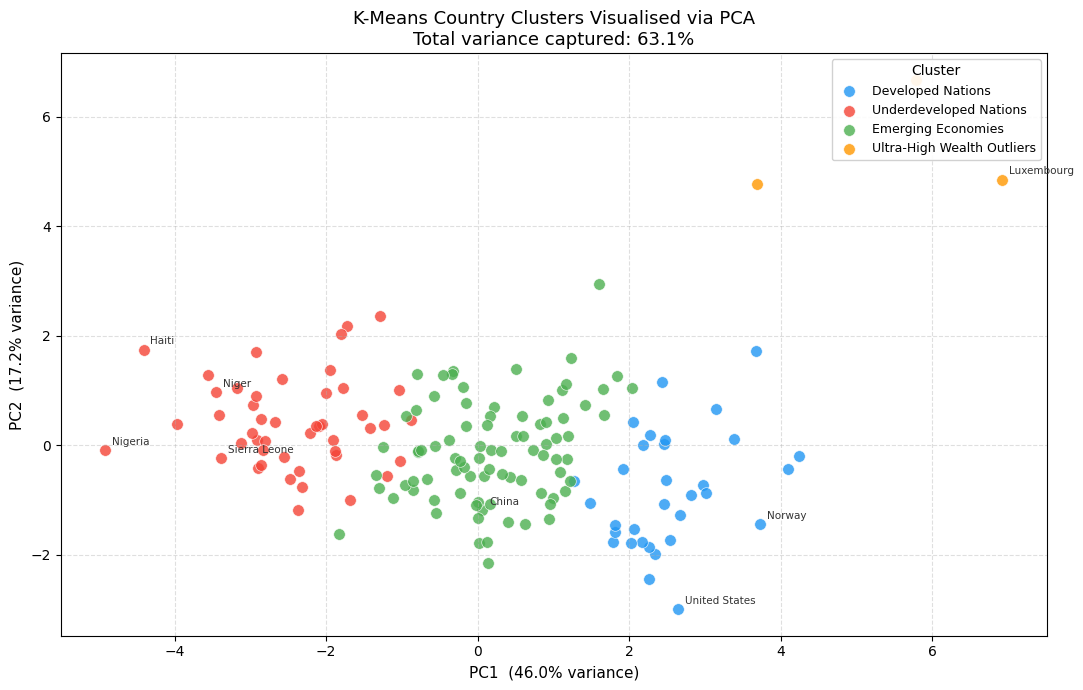

PC1 explains 46.0% | PC2 explains 17.2%
Combined variance captured: 63.1%


In [18]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_

viz_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': df['kmeans_cluster'].astype(str),
    'Country': df['country']
})

palette = {"0": "#2196F3", "1": "#F44336", "2": "#4CAF50", "3": "#FF9800"}
cluster_labels = {
    "0": "Developed Nations",
    "1": "Underdeveloped Nations",
    "2": "Emerging Economies",
    "3": "Ultra-High Wealth Outliers"
}

fig, ax = plt.subplots(figsize=(11, 7))
for cid, grp in viz_df.groupby('Cluster'):
    ax.scatter(
        grp['PC1'], grp['PC2'],
        label=cluster_labels[cid],
        color=palette[cid], s=70, alpha=0.80, edgecolors='white', linewidths=0.5
    )
highlight = ['Haiti', 'Niger', 'Sierra Leone', 'Luxembourg',
             'Norway', 'United States', 'China', 'Nigeria']
for _, row in viz_df[viz_df['Country'].isin(highlight)].iterrows():
    ax.annotate(
        row['Country'], (row['PC1'], row['PC2']),
        fontsize=7.5, xytext=(5, 4), textcoords='offset points', color='#333'
    )

ax.set_xlabel(f'PC1  ({var_explained[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2  ({var_explained[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(
    f'K-Means Country Clusters Visualised via PCA\n'
    f'Total variance captured: {sum(var_explained)*100:.1f}%',
    fontsize=13
)
ax.legend(title='Cluster', fontsize=9, title_fontsize=10,
          loc='upper right', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'PC1 explains {var_explained[0]*100:.1f}% | PC2 explains {var_explained[1]*100:.1f}%')
print(f'Combined variance captured: {sum(var_explained)*100:.1f}%')

## 9 · Cluster Profiling

In [19]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = [
    'Cluster 0 — Developed',
    'Cluster 1 — Underdeveloped',
    'Cluster 2 — Emerging',
    'Cluster 3 — Ultra-Wealthy'
]
display(profile.style
    .background_gradient(cmap='RdYlGn', subset=['income', 'gdpp', 'life_expec'])
    .background_gradient(cmap='RdYlGn_r', subset=['child_mort', 'inflation', 'total_fer'])
    .format('{:.2f}')
    .set_caption('Mean Socio-Economic Indicators by Cluster')
)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster 0 — Developed,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
Cluster 1 — Underdeveloped,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
Cluster 2 — Emerging,21.69,41.07,6.20,47.91,12671.41,7.61,72.87,2.30,6519.55
Cluster 3 — Ultra-Wealthy,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67


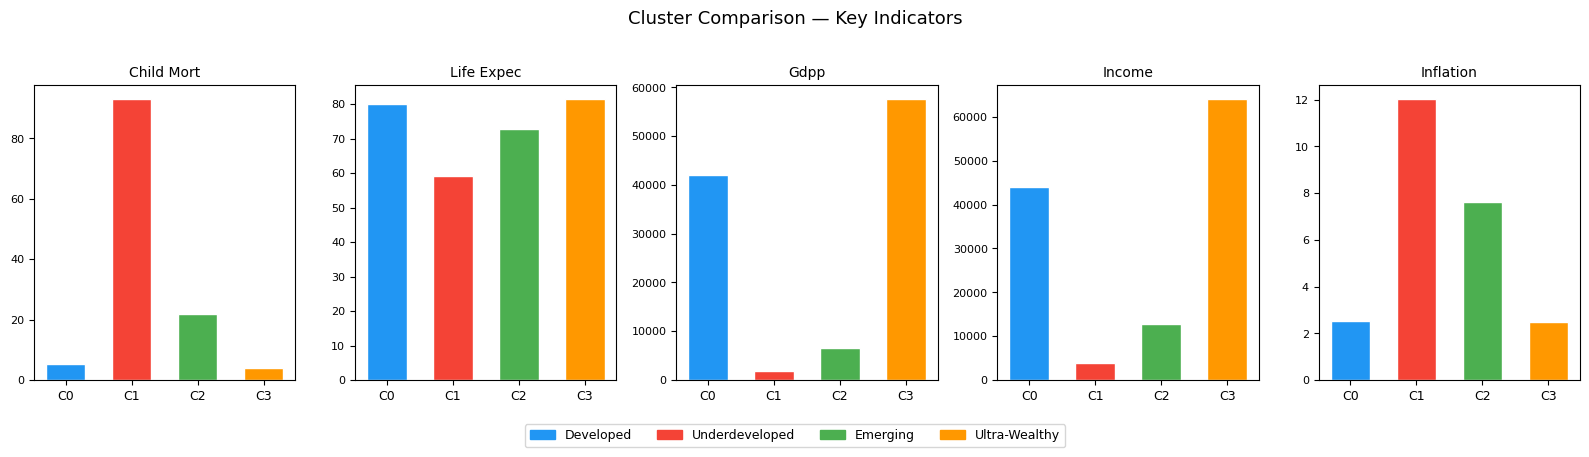

In [20]:
indicators = ['child_mort', 'life_expec', 'gdpp', 'income', 'inflation']
cluster_means = df.groupby('kmeans_cluster')[indicators].mean()

fig, axes = plt.subplots(1, len(indicators), figsize=(16, 4))
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
labels = ['Developed', 'Underdeveloped', 'Emerging', 'Ultra-Wealthy']

for ax, ind in zip(axes, indicators):
    vals = cluster_means[ind].values
    bars = ax.bar(range(4), vals, color=colors, edgecolor='white', width=0.6)
    ax.set_title(ind.replace('_', ' ').title(), fontsize=10)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['C0', 'C1', 'C2', 'C3'], fontsize=9)
    ax.yaxis.set_tick_params(labelsize=8)

plt.suptitle('Cluster Comparison — Key Indicators', fontsize=13, y=1.02)
legend_patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
fig.legend(handles=legend_patches, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 0.0), fontsize=9)
plt.tight_layout()
plt.show()

## 10 · Final Insights & Socio-Economic Observations

---

### Observation 1 — Which cluster carries the highest child mortality?
Cluster 1 represents the least developed countries, where child mortality is very high, with an average of 93 deaths per 1,000 live births. This is almost 18 times higher than Cluster 0 (Developed Nations), which has only 5 deaths per 1,000 live births. Countries such as Niger, Sierra Leone, Chad, and Mali fall into this group. These countries generally have low incomes (around USD 3,942 per person) and limited access to quality healthcare facilities. As a result, they also have lower life expectancy (about 59 years) and higher birth rates, with women having around 5 children on average. These characteristics are commonly seen in developing economies that are still in the early stages of economic and social development.


---

### Observation 2 — Which cluster shows high income and GDP per capita?

Cluster 0 consists of developed countries and has the highest average income and GDP per capita among the major clusters, with values of about USD 44,022 and USD 42,119 respectively. This group includes countries from Western Europe, North America, Australia, and other advanced economies. People in these countries generally enjoy a high standard of living, better healthcare, and longer life expectancy.

Cluster 3, which includes countries such as Luxembourg, Singapore, and Malta, has even higher income and GDP per capita values. On average, these countries have an income of around USD 64,033 and a GDP per capita of about USD 57,567. Their strong financial sectors, international trade activities, and smaller populations contribute to their exceptional economic performance. Both clusters also have high life expectancy (above 80 years) and low inflation rates, indicating stable and well-developed economies.

---

### Observation 3 — Which cluster appears underdeveloped?

Cluster 1 can be considered the most underdeveloped group among all the clusters. It has the lowest average GDP per capita (USD 1,922) and income levels (around USD 3,942), indicating weak economic conditions. This cluster also records the highest child mortality rate, with about 93 deaths per 1,000 live births, and the lowest life expectancy, averaging only 59 years.
Another notable feature is its high fertility rate of around 5 children per woman, which often reflects limited access to education, healthcare, and family planning services. In addition, the average inflation rate is relatively high at about 12%, suggesting economic and monetary instability. Most of the 47 countries in this cluster are located in Sub-Saharan Africa and parts of South Asia, which aligns with the characteristics commonly associated with the world's least developed countries.

---

### Observation 4 — Which countries should be prioritised for humanitarian aid?

Based on the clustering results, Cluster 1 should be given the highest priority for humanitarian aid. Within this cluster, countries such as Niger, Sierra Leone, Central African Republic, Chad, and Mali show the most critical conditions. These countries have very high child mortality rates, extremely low GDP per capita, and low life expectancy compared to other nations.

For example, Sierra Leone, Chad, and the Central African Republic have some of the highest child mortality rates in the dataset, while Niger and Mali also face severe economic challenges with very low income levels. The combination of poor health outcomes, low economic development, and limited access to essential services makes these countries particularly vulnerable.

To improve living conditions, aid efforts should focus on areas such as healthcare, nutrition, clean water, education, and child welfare. Investments in these sectors can help reduce child mortality, increase life expectancy, and support long-term economic and social development.

---

### Observation 5 — What does DBSCAN reveal beyond K-Means?

DBSCAN provides additional insights that are not easily visible with K-Means. Using the chosen parameters, it identified 30 countries (about 18% of the dataset) as outliers. These countries have unusual combinations of economic and social indicators that make them different from the majority of nations. For example, some countries may have high export levels despite low income, while others may be small economies with exceptionally high trade activity.

DBSCAN grouped most countries into one large cluster containing 137 countries, indicating that many nations share similar characteristics and form a continuous pattern rather than clearly separated groups. While DBSCAN is useful for detecting unusual or exceptional countries, K-Means provides more distinct and interpretable clusters, making it a better choice for segmenting countries based on their development and economic indicators in this dataset.



In [33]:
cluster_label_map = {
    0: 'Developed Nations',
    1: 'Underdeveloped Nations',
    2: 'Emerging Economies',
    3: 'Ultra-High Wealth Outliers'
}

for cid, label in cluster_label_map.items():
    countries = sorted(df.loc[df['kmeans_cluster'] == cid, 'country'].tolist())
    print(f'\n Cluster {cid}: {label} ({len(countries)} countries) ')
    print(', '.join(countries))


 Cluster 0: Developed Nations (32 countries) 
Australia, Austria, Bahamas, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Netherlands, New Zealand, Norway, Portugal, Qatar, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

 Cluster 1: Underdeveloped Nations (47 countries) 
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

 Cluster 2: Emerging Economies (85 countries) 
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia,

In [34]:
!pip -q install xgboost

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np

In [35]:

X_clf = X_scaled.copy()
y_clf = df['kmeans_cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Class distribution in test set:')
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u} ({cluster_label_map[u]}): {c} countries')

Training samples : 133
Test samples     : 34
Class distribution in test set:
  Cluster 0 (Developed Nations): 6 countries
  Cluster 1 (Underdeveloped Nations): 10 countries
  Cluster 2 (Emerging Economies): 17 countries
  Cluster 3 (Ultra-High Wealth Outliers): 1 countries


In [36]:

lr_clf = LogisticRegression(C=0.1, max_iter=1000, random_state=42)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

stacking_clf = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=0.1, max_iter=1000, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                               use_label_encoder=False, eval_metric='mlogloss',
                               random_state=42))
    ],
    final_estimator=LogisticRegression(C=0.01, max_iter=1000),
    cv=5,
    stack_method='predict_proba'
)

models = {
    'Logistic Regression': lr_clf,
    'Random Forest'      : rf_clf,
    'XGBoost'            : xgb_clf,
    'Stacking Ensemble'  : stacking_clf
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Model":<25} {"CV Accuracy":>12} {"Test Accuracy":>14}')
print('─' * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    cv_score  = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()
    test_score = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'cv': cv_score, 'test': test_score, 'model': model}
    print(f'{name:<25} {cv_score*100:>11.2f}%  {test_score*100:>12.2f}%')

Model                      CV Accuracy  Test Accuracy
───────────────────────────────────────────────────────
Logistic Regression             93.25%         91.18%
Random Forest                   95.53%         94.12%
XGBoost                         91.77%         94.12%
Stacking Ensemble               69.23%         79.41%


In [37]:

best_name = max(results, key=lambda k: results[k]['test'])
best_model = results[best_name]['model']
y_pred = best_model.predict(X_test)

print(f'Best Model: {best_name}')
print(f'Test Accuracy: {results[best_name]["test"]*100:.2f}%')
print()

target_names = [cluster_label_map[i] for i in sorted(cluster_label_map)]
print(classification_report(y_test, y_pred, target_names=target_names))

Best Model: Random Forest
Test Accuracy: 94.12%

                            precision    recall  f1-score   support

         Developed Nations       1.00      0.83      0.91         6
    Underdeveloped Nations       1.00      1.00      1.00        10
        Emerging Economies       0.89      1.00      0.94        17
Ultra-High Wealth Outliers       0.00      0.00      0.00         1

                  accuracy                           0.94        34
                 macro avg       0.72      0.71      0.71        34
              weighted avg       0.92      0.94      0.93        34



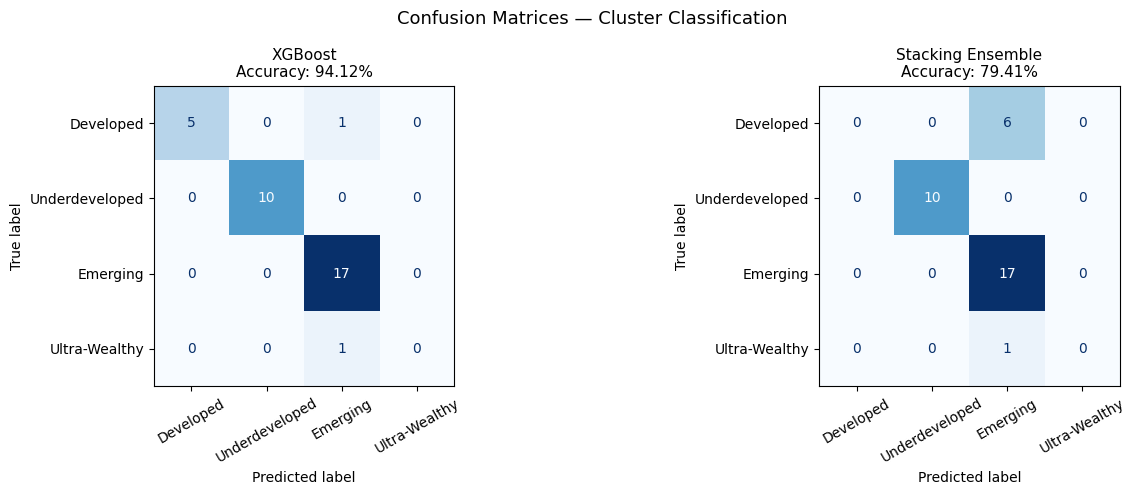

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res) in zip(axes, [
    ('XGBoost', results['XGBoost']),
    ('Stacking Ensemble', results['Stacking Ensemble'])
]):
    cm = confusion_matrix(y_test, res['model'].predict(X_test))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Developed', 'Underdeveloped', 'Emerging', 'Ultra-Wealthy']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {res["test"]*100:.2f}%', fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — Cluster Classification', fontsize=13)
plt.tight_layout()
plt.show()

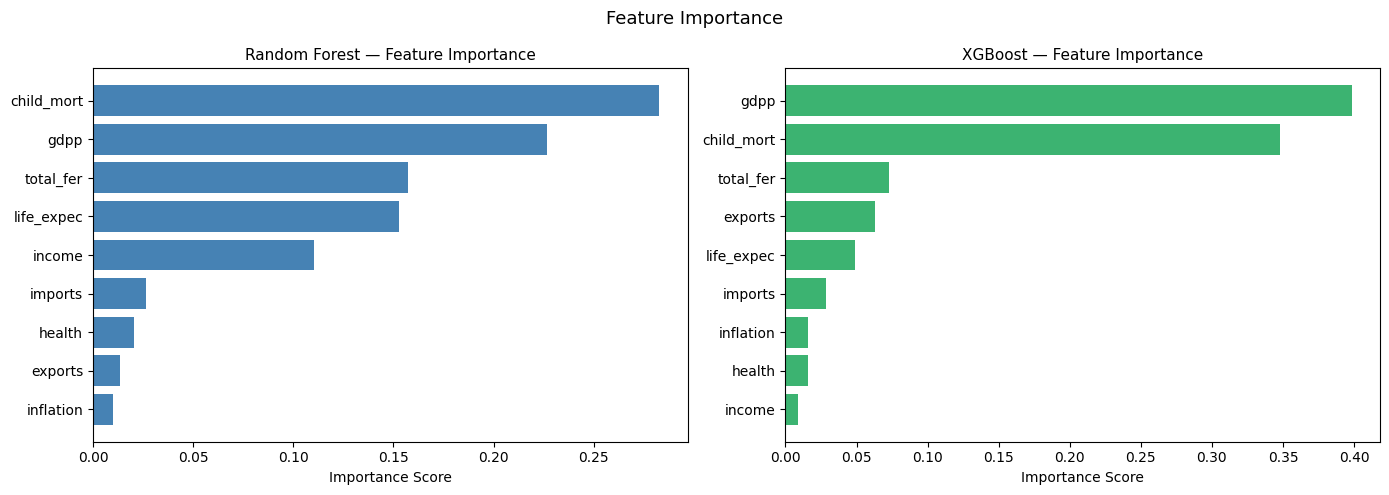

Top 3 features driving cluster classification:
  child_mort      RF importance: 0.2827
  gdpp            RF importance: 0.2268
  total_fer       RF importance: 0.1572


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest importance
rf_importance = results['Random Forest']['model'].feature_importances_
sorted_idx_rf = np.argsort(rf_importance)[::-1]
axes[0].barh(
    [numeric_cols[i] for i in sorted_idx_rf],
    rf_importance[sorted_idx_rf],
    color='steelblue'
)
axes[0].set_title('Random Forest — Feature Importance', fontsize=11)
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

# XGBoost importance
xgb_importance = results['XGBoost']['model'].feature_importances_
sorted_idx_xgb = np.argsort(xgb_importance)[::-1]
axes[1].barh(
    [numeric_cols[i] for i in sorted_idx_xgb],
    xgb_importance[sorted_idx_xgb],
    color='mediumseagreen'
)
axes[1].set_title('XGBoost — Feature Importance', fontsize=11)
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 3 features driving cluster classification:')
for i in sorted_idx_rf[:3]:
    print(f'  {numeric_cols[i]:<15} RF importance: {rf_importance[i]:.4f}')

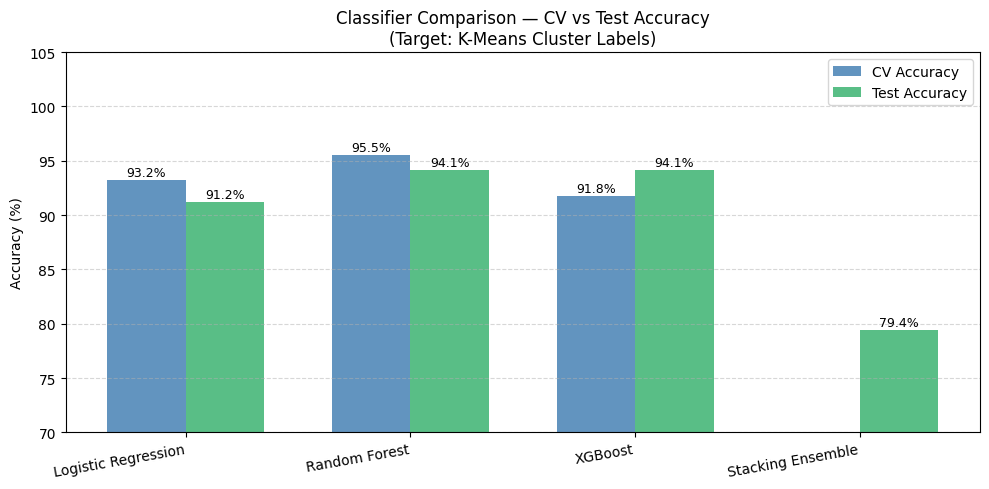

In [40]:
names  = list(results.keys())
cv_scores   = [results[n]['cv'] * 100   for n in names]
test_scores = [results[n]['test'] * 100 for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, cv_scores,   width, label='CV Accuracy',   color='steelblue',      alpha=0.85)
bars2 = ax.bar(x + width/2, test_scores, width, label='Test Accuracy', color='mediumseagreen', alpha=0.85)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Classifier Comparison — CV vs Test Accuracy\n(Target: K-Means Cluster Labels)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10, ha='right')
ax.set_ylim(70, 105)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [41]:
def predict_country_cluster(indicators: dict, model=None) -> str:
    if model is None:
        model = best_model

    row = np.array([[indicators[col] for col in numeric_cols]])
    row_scaled = scaler.transform(row)
    cluster_id = model.predict(row_scaled)[0]
    proba = model.predict_proba(row_scaled)[0]

    print(f'Predicted Cluster : {cluster_id} — {cluster_label_map[cluster_id]}')
    print('Confidence scores :')
    for i, p in enumerate(proba):
        print(f'  Cluster {i} ({cluster_label_map[i]:<30}): {p*100:.1f}%')
    return cluster_label_map[cluster_id]

print(' Example 1: Developed Nation Profile ')
predict_country_cluster({
    'child_mort': 5.0,
    'exports'   : 42.0,
    'health'    : 9.5,
    'imports'   : 38.0,
    'income'    : 40000,
    'inflation' : 1.8,
    'life_expec': 81.0,
    'total_fer' : 1.6,
    'gdpp'      : 42000
})

print()

print('Example 2: Underdeveloped Nation Profile')
predict_country_cluster({
    'child_mort': 110.0,
    'exports'   : 12.0,
    'health'    : 3.5,
    'imports'   : 18.0,
    'income'    : 1500,
    'inflation' : 14.0,
    'life_expec': 57.0,
    'total_fer' : 5.5,
    'gdpp'      : 800
})

 Example 1: Developed Nation Profile 
Predicted Cluster : 0 — Developed Nations
Confidence scores :
  Cluster 0 (Developed Nations             ): 99.1%
  Cluster 1 (Underdeveloped Nations        ): 0.0%
  Cluster 2 (Emerging Economies            ): 0.9%
  Cluster 3 (Ultra-High Wealth Outliers    ): 0.0%

Example 2: Underdeveloped Nation Profile
Predicted Cluster : 1 — Underdeveloped Nations
Confidence scores :
  Cluster 0 (Developed Nations             ): 0.0%
  Cluster 1 (Underdeveloped Nations        ): 94.9%
  Cluster 2 (Emerging Economies            ): 5.1%
  Cluster 3 (Ultra-High Wealth Outliers    ): 0.0%


'Underdeveloped Nations'